In [17]:
# %% [markdown]
# 🧠 Brain Tumor Classification - Final Stable Version (10 Epochs)

# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Create folders
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# %%

Using device: cpu


In [18]:
# ✅ TRANSFORMS - MATCHING PDF (224×224, same as baseline)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # ← Back to 224!
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # ← Same as PDF
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [4]:
# TRANSFORMS
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [19]:
# ✅ LOAD DATA - FIXED METHOD
# Load full dataset first without transforms
full_dataset = datasets.ImageFolder("../data/raw/Training", transform=None)
num_classes = len(full_dataset.classes)
print(f"Classes: {full_dataset.classes}")

# Split indices
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Use random_split on the dataset directly
train_data, val_data = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
# Create a proper wrapper to apply transforms
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.dataset)

train_dataset = ApplyTransform(train_data, train_transforms)
val_dataset = ApplyTransform(val_data, val_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 4480 | Val: 1120


In [20]:
# ✅ MODEL - MATCHING PDF BASELINE ARCHITECTURE
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 3→32 (matching PDF)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224→112
            
            # Block 2: 32→64 (matching PDF)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112→56
            
            # Block 3: 64→128 (matching PDF)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56→28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),  # ← Same as PDF
            nn.ReLU(),
            nn.Linear(512, num_classes)       # ← Same as PDF
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(model)


Total parameters: 51,476,036
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [22]:
# ✅ TRAINING SETUP - MATCHING PDF
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # ← Same as PDF

# %%
# ✅ TRAINING FUNCTION
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


In [23]:
# ✅ TRAINING - 10 EPOCHS (matching PDF)
num_epochs = 10
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("\n" + "=" * 70)
print("TRAINING BASELINE CNN (10 Epochs)")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Save model
torch.save(model.state_dict(), '../models/baseline_match.pth')
print("\n✅ Model saved!")

# %%


TRAINING BASELINE CNN (10 Epochs)
Epoch  1/10 | Train Loss: 0.7763 | Train Acc: 69.98% | Val Loss: 0.5210 | Val Acc: 82.23%
Epoch  2/10 | Train Loss: 0.4338 | Train Acc: 83.39% | Val Loss: 0.3563 | Val Acc: 85.89%
Epoch  3/10 | Train Loss: 0.2963 | Train Acc: 88.53% | Val Loss: 0.2874 | Val Acc: 88.66%
Epoch  4/10 | Train Loss: 0.2063 | Train Acc: 92.68% | Val Loss: 0.2752 | Val Acc: 90.62%
Epoch  5/10 | Train Loss: 0.1553 | Train Acc: 94.22% | Val Loss: 0.2330 | Val Acc: 90.89%
Epoch  6/10 | Train Loss: 0.1146 | Train Acc: 96.38% | Val Loss: 0.1757 | Val Acc: 94.46%
Epoch  7/10 | Train Loss: 0.1104 | Train Acc: 96.27% | Val Loss: 0.2191 | Val Acc: 93.12%
Epoch  8/10 | Train Loss: 0.0722 | Train Acc: 97.41% | Val Loss: 0.1733 | Val Acc: 95.27%
Epoch  9/10 | Train Loss: 0.0576 | Train Acc: 97.90% | Val Loss: 0.1711 | Val Acc: 95.09%
Epoch 10/10 | Train Loss: 0.0560 | Train Acc: 98.10% | Val Loss: 0.1407 | Val Acc: 96.25%

✅ Model saved!


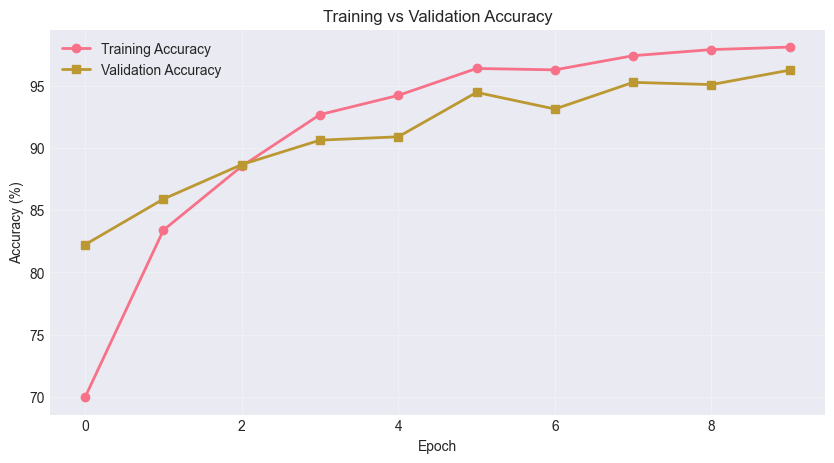

In [24]:
# 📈 ACCURACY GRAPH
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Training Accuracy', linewidth=2, marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/accuracy.png', dpi=300, bbox_inches='tight')
plt.show()


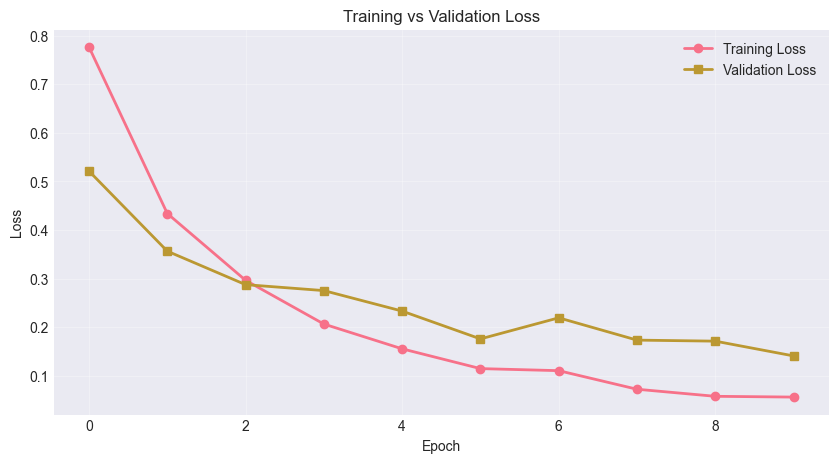

In [25]:
# 📉 LOSS GRAPH
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', linewidth=2, marker='o')
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# 🧪 TEST EVALUATION
test_dataset = datasets.ImageFolder("../data/raw/Testing", transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


In [27]:
# 📊 RESULTS
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(all_labels, all_preds)
print("\n" + "=" * 50)
print(f"OVERALL TEST ACCURACY: {test_acc*100:.2f}%")
print("=" * 50)

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


OVERALL TEST ACCURACY: 92.31%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.95      0.79      0.86       400
  meningioma       0.91      0.92      0.91       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.98      0.99      0.99       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



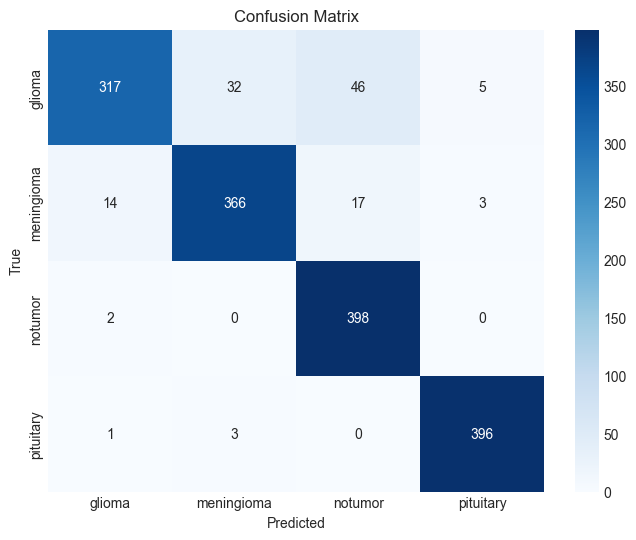

In [28]:
# 📊 CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('../results/figures/confusion.png', dpi=300, bbox_inches='tight')
plt.show()


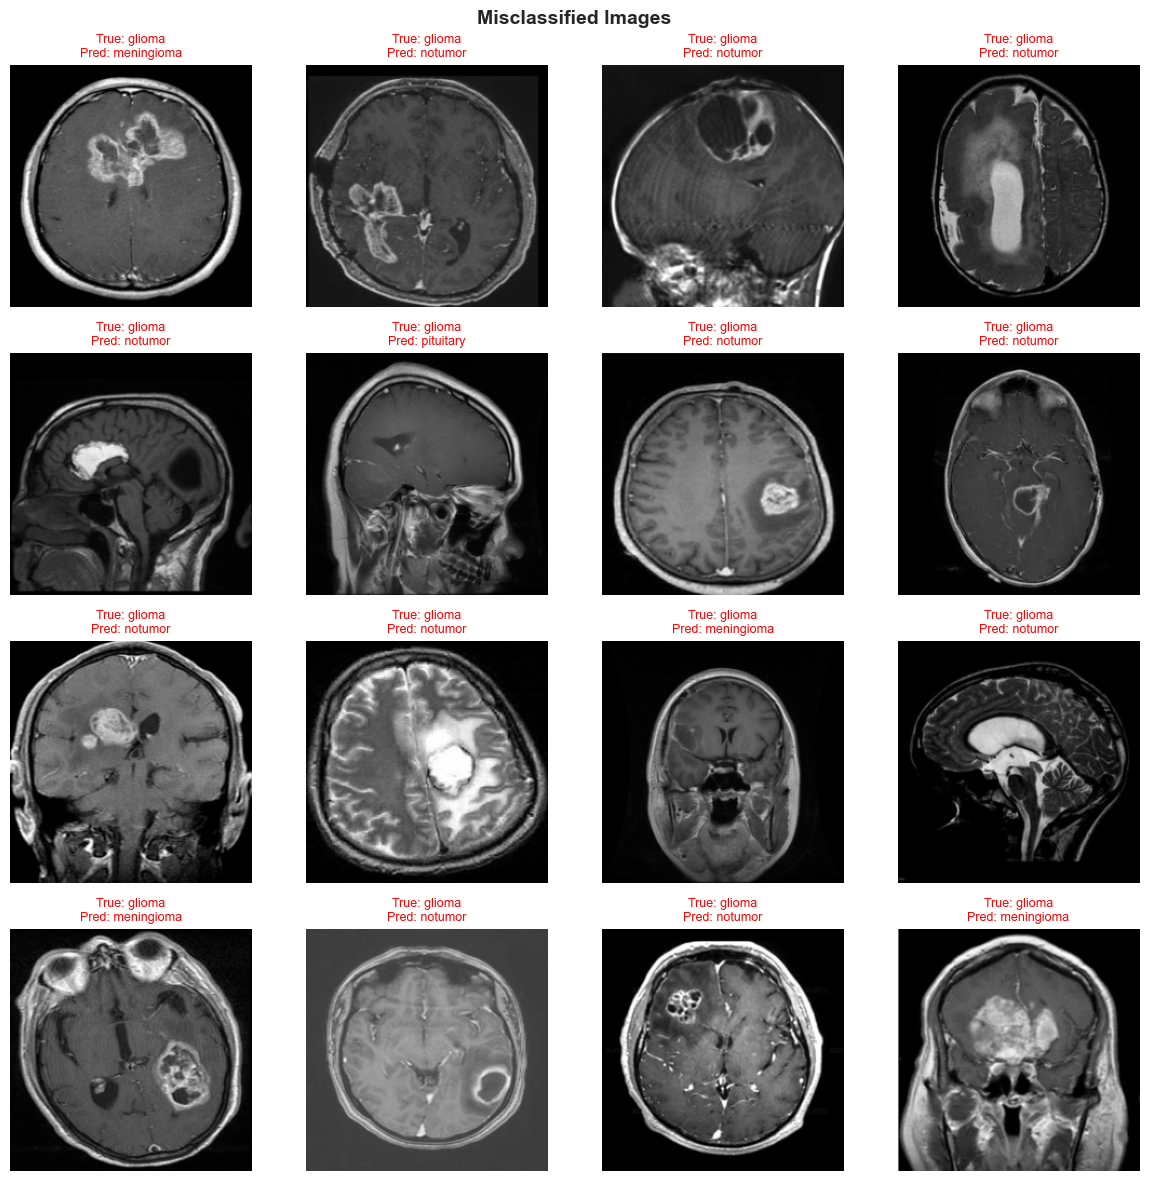


Total misclassified shown: 16

✅ ANALYSIS COMPLETE


In [29]:
# ❌ MISCLASSIFIED IMAGES
def show_misclassified(model, loader, classes, max_show=16):
    model.eval()
    wrong_images = []
    wrong_true = []
    wrong_pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            _, preds = outputs.max(1)
            
            for i in range(len(images)):
                if preds[i] != labels[i]:
                    wrong_images.append(images[i])
                    wrong_true.append(labels[i].item())
                    wrong_pred.append(preds[i].item())
                if len(wrong_images) >= max_show:
                    break
            if len(wrong_images) >= max_show:
                break
    
    if wrong_images:
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))
        for i, ax in enumerate(axes.flat):
            if i < len(wrong_images):
                img = wrong_images[i]
                img = img * 0.5 + 0.5  # Denormalize
                ax.imshow(img.permute(1, 2, 0))
                ax.set_title(f'True: {classes[wrong_true[i]]}\nPred: {classes[wrong_pred[i]]}',
                           color='red', fontsize=9)
            ax.axis('off')
        
        plt.suptitle('Misclassified Images', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../results/figures/misclassified.png', dpi=300)
        plt.show()
        
        print(f"\nTotal misclassified shown: {len(wrong_images)}")

show_misclassified(model, test_loader, test_dataset.classes)

print("\n✅ ANALYSIS COMPLETE")